In [1]:
import sys
sys.path.append("./src")

In [2]:
from data import DSBuilder, LMKBCDataset

In [3]:
import os
from transformers import AutoTokenizer
from utils import prepare_tokenizer, prepare_model

data_dir = "./data/lmkbc/2022"
n_ref_min = 50
n_ref_max = 50
seed = 42

n_token_gp = 4

n_token_tensor = 1

sentence_emb_mode = "ke"
sentence_emb_idx = 11

lm = "openai-community/gpt2"

tokenizer = prepare_tokenizer(AutoTokenizer.from_pretrained(lm))

builder = DSBuilder(
    triples_path=os.path.join(data_dir, "triples.json"),
    data_path=os.path.join(data_dir, "train.jsonl"),
    n_reference_min=n_ref_min,
    n_reference_max=n_ref_max,
    stay_ratio_min=0.0,
    stay_ratio_max=0.0,
    random_state=seed,
    n_pick=1,
    items_path=os.path.join(data_dir, "train-items.jsonl"),
    save_items=False,
    load=True
)

texts_tensor_path = os.path.join(data_dir, f"texts.{lm.replace('/', '_')}.n_token={n_token_tensor}.index={sentence_emb_idx}.tensor")
texts_tensor_path = texts_tensor_path if os.path.exists(texts_tensor_path) else os.path.join(data_dir, f"texts.{lm.replace('/', '_')}.n_token={n_token_tensor}.tensor")

entities_tensor_path = os.path.join(data_dir, f"entities.{lm.replace('/', '_')}.n_token={n_token_tensor}.index={sentence_emb_idx}.tensor")
entities_tensor_path = entities_tensor_path if os.path.exists(entities_tensor_path) else os.path.join(data_dir, f"entities.n_token={n_token_tensor}.tensor")

relations_tensor_path = os.path.join(data_dir, f"relations.{lm.replace('/', '_')}.n_token={n_token_tensor}.index={sentence_emb_idx}.tensor")
relations_tensor_path = relations_tensor_path if os.path.exists(relations_tensor_path) else os.path.join(data_dir, f"relations.n_token={n_token_tensor}.tensor")

ds = LMKBCDataset(
    builder,
    os.path.join(data_dir, "texts.txt"),
    os.path.join(data_dir, "entities.txt"),
    os.path.join(data_dir, "relations.txt"),
    os.path.join(data_dir, "entities_alias.jsonl"),
    n_tokens=n_token_gp,
    tokenizer=tokenizer,
    texts_tensor_path=texts_tensor_path,
    entities_tensor_path=entities_tensor_path,
    relations_tensor_path=relations_tensor_path,
    sentence_emb_mode=sentence_emb_mode,
    sentence_emb_index=sentence_emb_idx
)

In [4]:
prompt_idx = 0

_ = ds.prepare_train(prompt_idx=prompt_idx)

0it [00:00, ?it/s]

Get wikidata id request timeout, redo request...


1200it [00:25, 47.20it/s] 


In [5]:
from model import KGATModel, AutoModelForLMKBC, GraphPrefix, Pipeline

In [6]:
kgat_model = KGATModel(
    d_model=768,
    d_ff=758//2,
    heads=8,
    beta=False,
    dropout=0.0,
    bias=True,
    transform_relation=False,
    num_block=2
)

# KGATModel.load(path) # use this instead for loading checkpoint

language_model = AutoModelForLMKBC.from_pretrained(lm, device_map="auto", output_attentions=True)
language_model = prepare_model(language_model, tokenizer)

graph_prefix = GraphPrefix(in_channels=ds.texts_attr.shape[1], d_model=language_model.embed_dim, n_token=n_token_gp, bias=True)

# GraphPrefix.load(path) # use this instead for loading checkpoint

pipe = Pipeline(kgat_model=kgat_model, graph_prefix=graph_prefix, language_model=language_model)

In [7]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
pipe.kgat_model.to(device)
pipe.graph_prefix.to(device)

GraphPrefix(
  (lin): Linear(768, 3072, bias=True)
)

# 1. Explain By Language Model

In [8]:
data_index = 2

In [9]:
ds[data_index][-2]

'Based on the knowledge graph `<KNOWLEDGE_GRAPH><KNOWLEDGE_GRAPH><KNOWLEDGE_GRAPH><KNOWLEDGE_GRAPH>` => (subject : Acetaldehyde | relation : ChemicalCompoundElement | object : oxygen | TRUE)'

In [10]:
tokenizer.batch_decode(ds.get(data_index)["input_ids"])

['Based on the knowledge graph `<KNOWLEDGE_GRAPH><KNOWLEDGE_GRAPH><KNOWLEDGE_GRAPH><KNOWLEDGE_GRAPH>` => (subject : Acetaldehyde | relation : ChemicalCompoundElement | object : oxygen | TRUE)<|endoftext|>']

In [11]:
from utils import KG_MASK

explain_prompt = f"`{KG_MASK*n_token_gp}` explain about " # ....

In [12]:
explain_inputs = tokenizer(explain_prompt, return_tensors="pt")

In [13]:
batch = ds.get(data_index)
batch.pop("weight")
batch.pop("labels")
batch.update(explain_inputs)
batch["n_token"] = n_token_gp

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

In [14]:
out = pipe.generate_lmkbc(**batch)

`GPT2SdpaAttention` is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [15]:
tokenizer.batch_decode(out)

['\xa0 the "The "The "The "The "']

# 2. Explain By Attention

In [16]:
batch = ds.get(data_index)
batch.pop("weight")
batch.pop("labels")
batch["n_token"] = n_token_gp

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

In [17]:
out = pipe.forward_lmkbc(**batch)

In [18]:
attention = out[-1]  # Retrieve attention from model outputs
tokens = tokenizer.convert_ids_to_tokens(batch["input_ids"][0])  # Convert input ids to token strings

This tool is designed for shorter inputs and may run slowly if the input text is very long and/or the model is very large. To mitigate this, you may wish to filter the layers displayed by setting the include_layers parameter, as described above.

In [21]:
from bertviz import model_view

model_view(attention, tokens, include_layers=[11], display_mode="light")

<IPython.core.display.Javascript object>

# 3. Explain By Retrieval Result

In [20]:
batch = ds.get(data_index)
batch.pop("weight")
batch.pop("labels")
batch.pop("input_ids")
batch.pop("attention_mask")

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

In [21]:
with torch.no_grad():
    out = kgat_model(**batch)

In [22]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(data_index, weights, spring=False):
    triples = []

    for t in ds.triples[ds[data_index][2]]:
        triples.append((
            ds.entities[ds.entities_alias.loc[t[0], "alias_idx"][0]],
            ds.relations[t[1]],
            ds.entities[ds.entities_alias.loc[t[2], "alias_idx"][0]]
        ))
    
    # Create a graph and add edges with labels
    G = nx.Graph()
    for (s, r, o), w in zip(triples, weights):
        G.add_edge(s, o, label=r, weight=w.item())
    
    # Choose a layout for the graph
    pos = nx.circular_layout(G) if not spring else nx.spring_layout(G)

    # Draw the graph
    plt.figure(figsize=(16, 12))
    # nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='black', node_size=200, font_size=5)
    nx.draw_networkx_nodes(G, pos, node_size=150)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

    # Draw edge labels
    edge_labels = nx.get_edge_attributes(G, 'label')
    edges = G.edges(data=True)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=[d['weight'] * 2 for (u, v, d) in edges], edge_color='black')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    # Show the plot
    plt.show()

In [23]:
weights = out.sigmoid().view(-1)

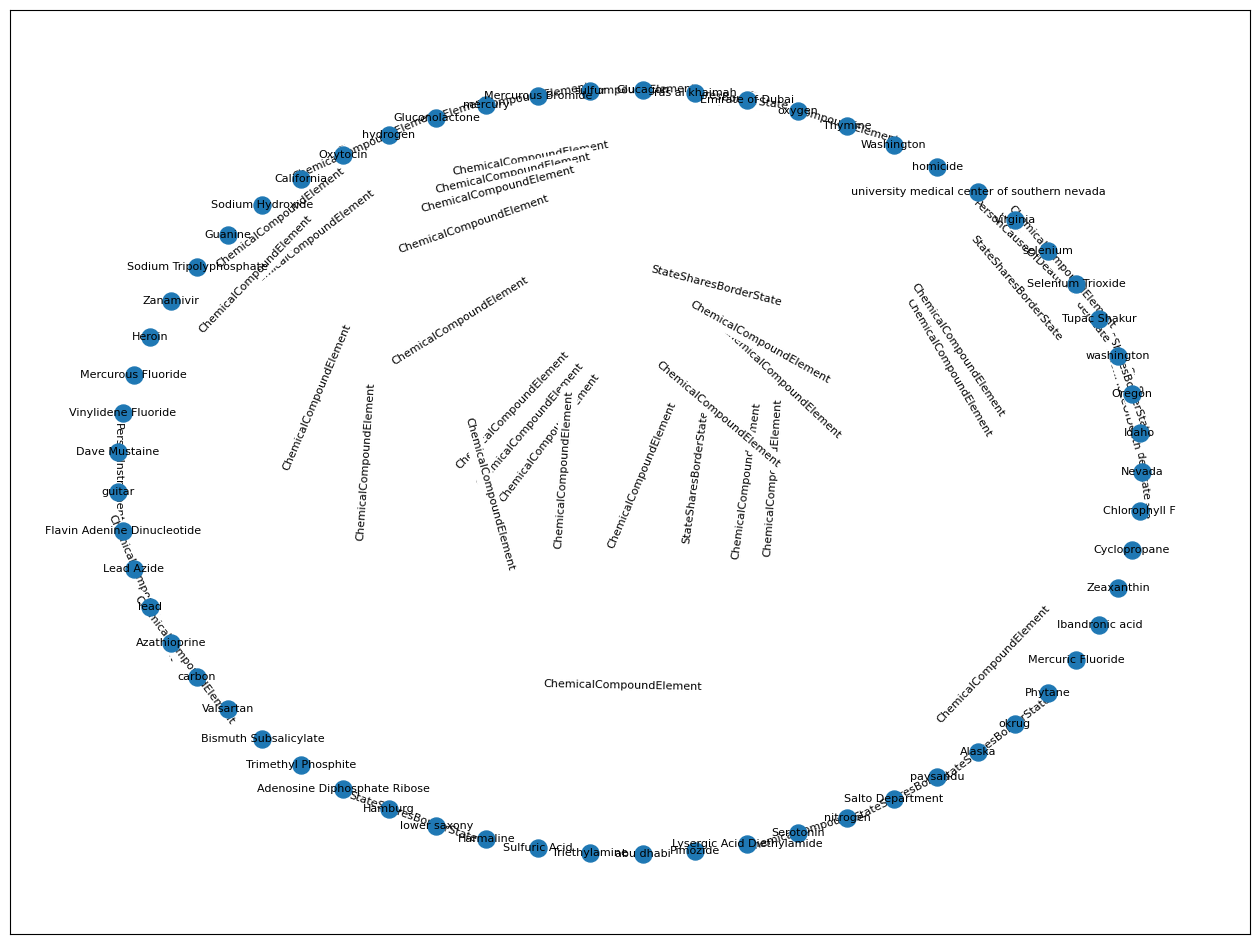

In [24]:
visualize_graph(data_index, weights)

# 4. Explain By Attention Encoder

In [29]:
with torch.no_grad():
    out = kgat_model.encode(batch["x"], batch["edge_index"], batch["relations"], return_attention_weights=True)

In [30]:
layer_idx = 0
head_idx = 5

weights = out[-1][1][layer_idx][:,head_idx]

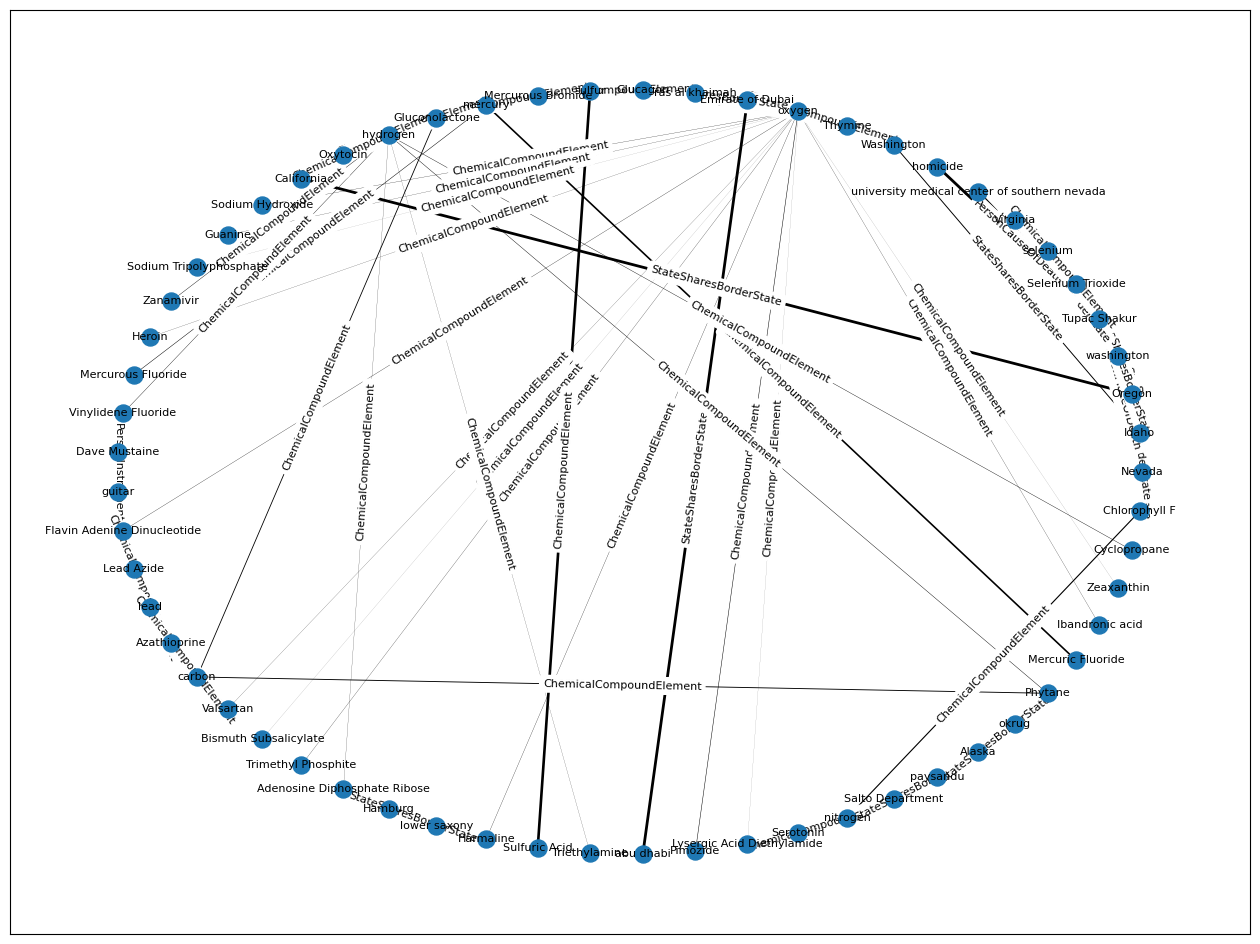

In [31]:
visualize_graph(data_index, weights)

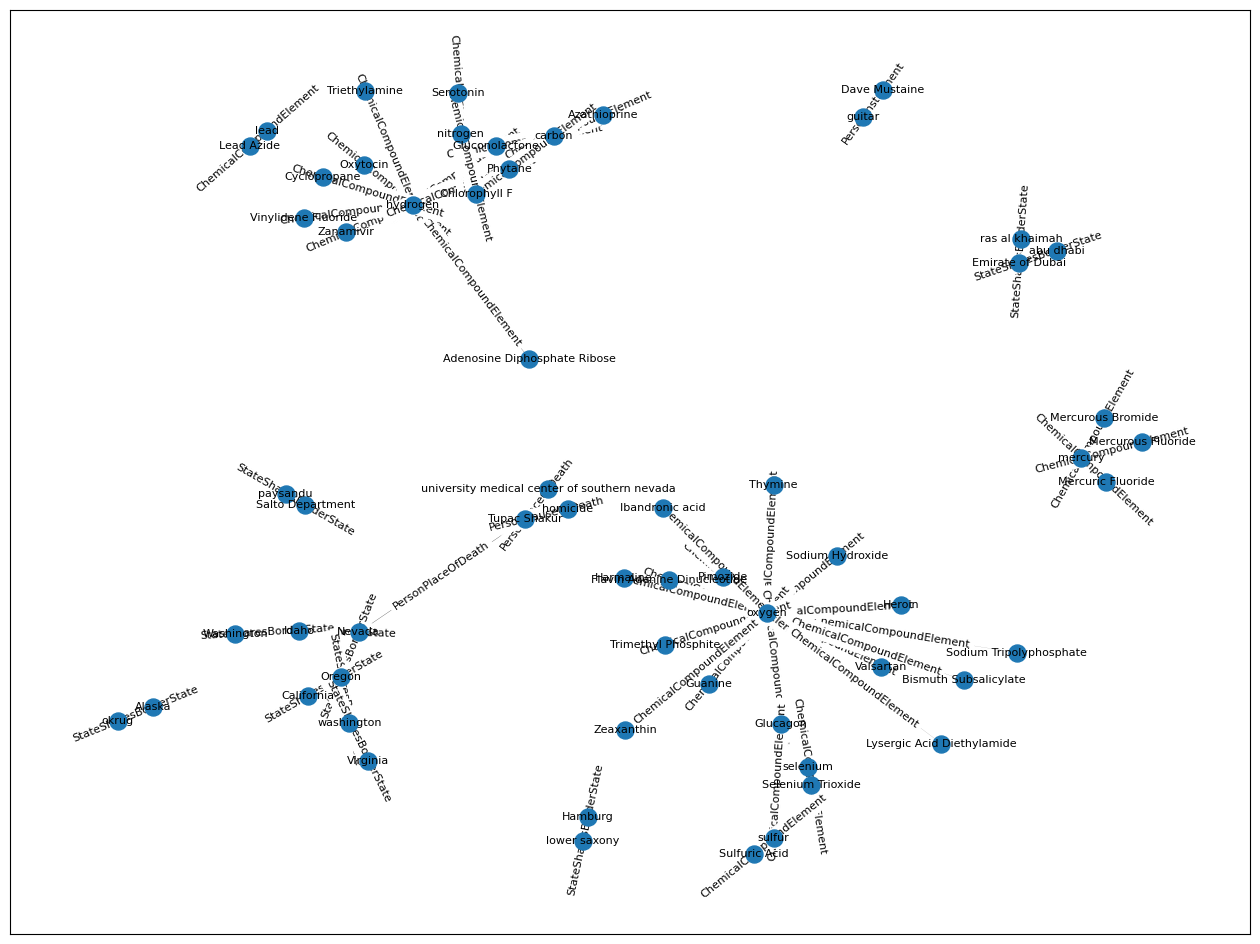

In [32]:
visualize_graph(data_index, weights, spring=True)